<a href="https://colab.research.google.com/github/teejay541/HOUSE-PRICE-PREDICTION/blob/main/homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('/content/actaruslab_f1_telemetry_2026.csv')
display(df.head())

,speed_kmh,wing_angle_deg,drs_active,downforce_n,drag_n,stability_index
0,199.25,7.08,0,577.87,96.66,100.00
1,351.94,22.57,0,5617.09,378.93,44.15
2,293.98,28.97,0,4945.14,300.02,77.74
3,258.64,27.93,0,3702.69,227.46,100.00
4,141.34,30.12,1,1184.59,53.24,100.00


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speed_kmh        150000 non-null  float64
 1   wing_angle_deg   150000 non-null  float64
 2   drs_active       150000 non-null  int64  
 3   downforce_n      150000 non-null  float64
 4   drag_n           150000 non-null  float64
 5   stability_index  150000 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 6.9 MB
None


In [5]:
display(df.describe())

,speed_kmh,wing_angle_deg,drs_active,downforce_n,drag_n,stability_index
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,232.568436,20.021099,0.298973,2393.564281,166.173028,91.333445
std,76.464660,8.660498,0.457810,1844.336840,106.490270,24.773129
min,100.000000,5.000000,0.000000,105.170000,18.050000,0.000000
25%,166.180000,12.520000,0.000000,929.890000,74.437500,100.000000
50%,232.870000,20.030000,0.000000,1840.785000,145.955000,100.000000
75%,298.850000,27.500000,1.000000,3426.025000,240.160000,100.000000
max,365.000000,35.000000,1.000000,8978.760000,519.460000,100.000000


,Missing Count,Missing Percentage


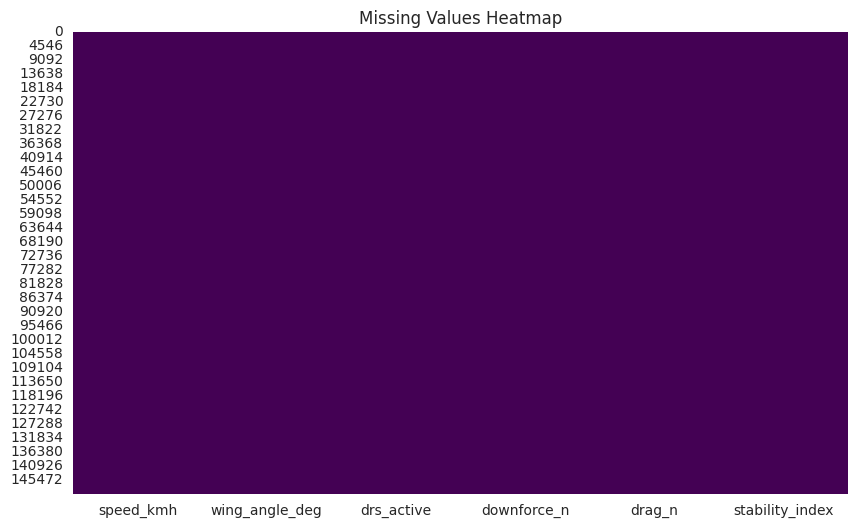

In [6]:
# Calculate and display the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

# Filter to show only columns with missing values and sort them
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

# Visualize missing values (optional, for larger datasets this helps to see patterns)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [8]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(150000, 6)

Column Names:
['speed_kmh', 'wing_angle_deg', 'drs_active', 'downforce_n', 'drag_n', 'stability_index']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speed_kmh        150000 non-null  float64
 1   wing_angle_deg   150000 non-null  float64
 2   drs_active       150000 non-null  int64  
 3   downforce_n      150000 non-null  float64
 4   drag_n           150000 non-null  float64
 5   stability_index  150000 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 6.9 MB


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [10]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (149999, 6)


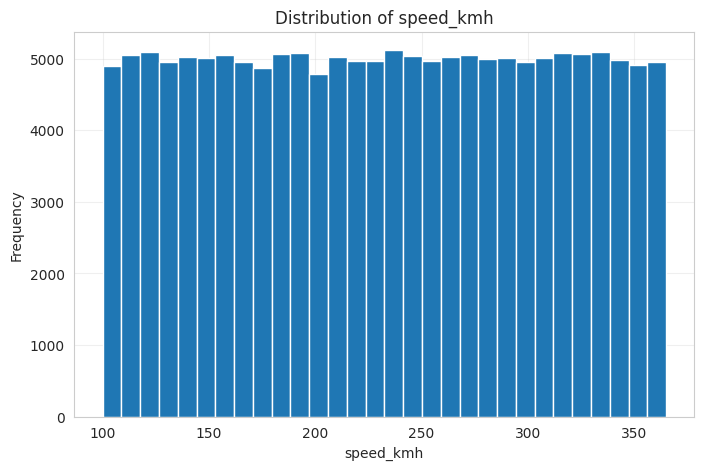

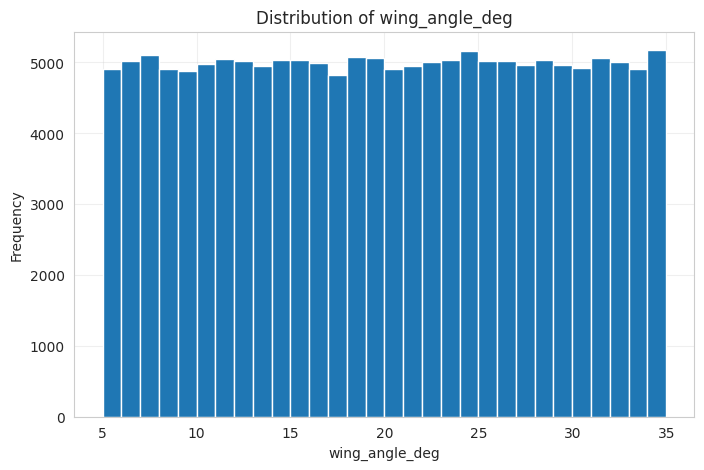

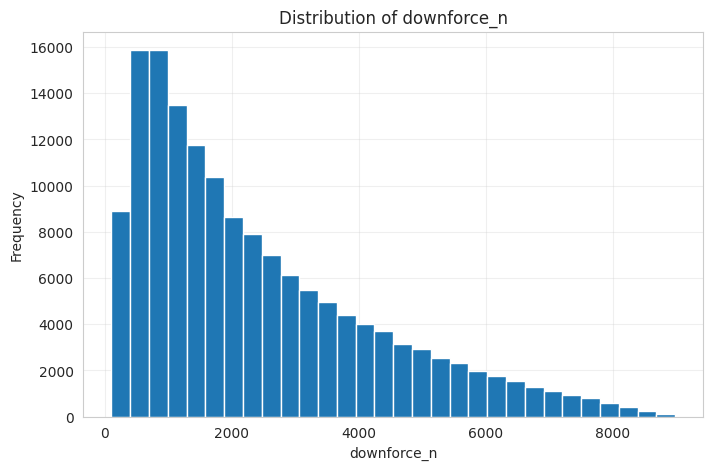

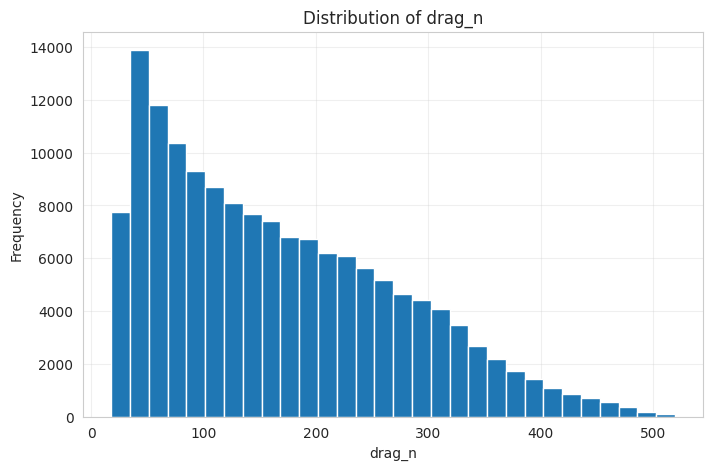

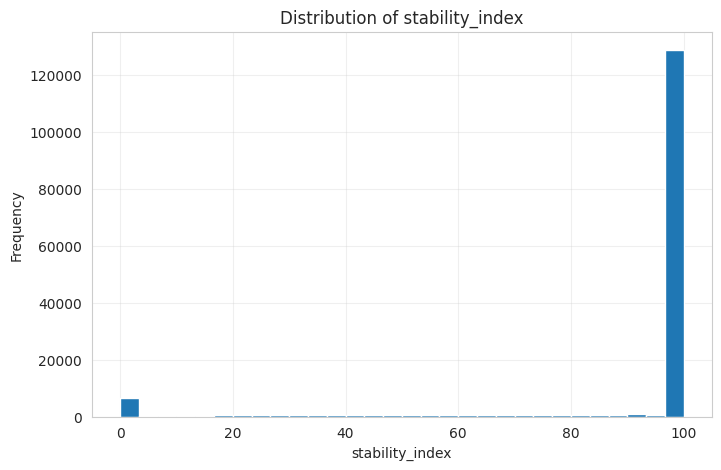

In [11]:
numeric_columns = [
    "speed_kmh",
    "wing_angle_deg",
    "downforce_n",
    "drag_n",
    "stability_index"
]

for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

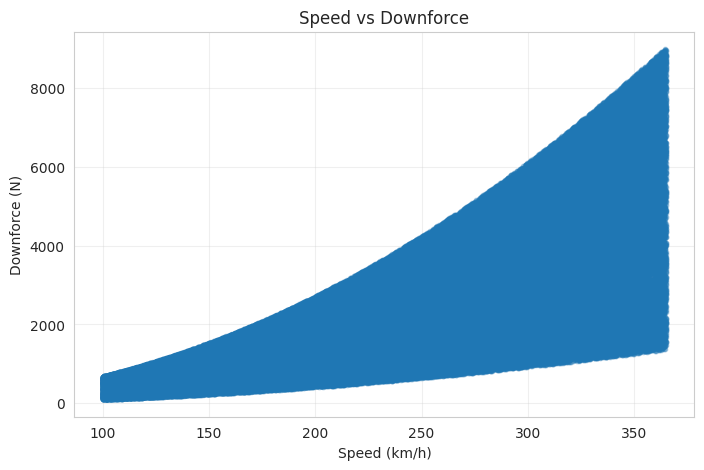

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["speed_kmh"],
    df["downforce_n"],
    alpha=0.3,
    s=10
)

plt.title("Speed vs Downforce")
plt.xlabel("Speed (km/h)")
plt.ylabel("Downforce (N)")
plt.grid(alpha=0.3)
plt.show()

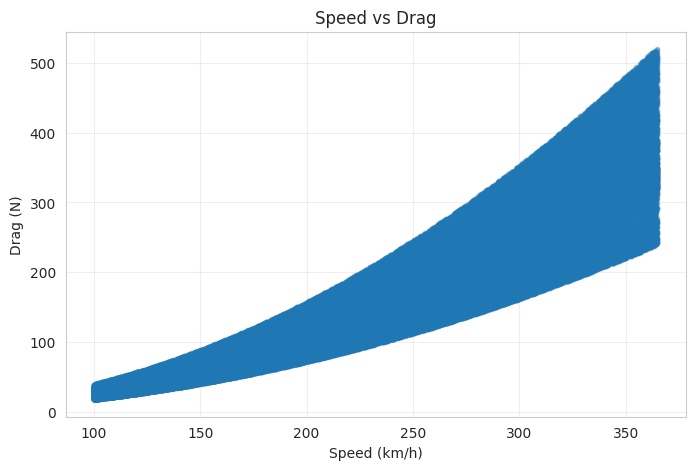

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["speed_kmh"],
    df["drag_n"],
    alpha=0.3,
    s=10
)

plt.title("Speed vs Drag")
plt.xlabel("Speed (km/h)")
plt.ylabel("Drag (N)")
plt.grid(alpha=0.3)
plt.show()

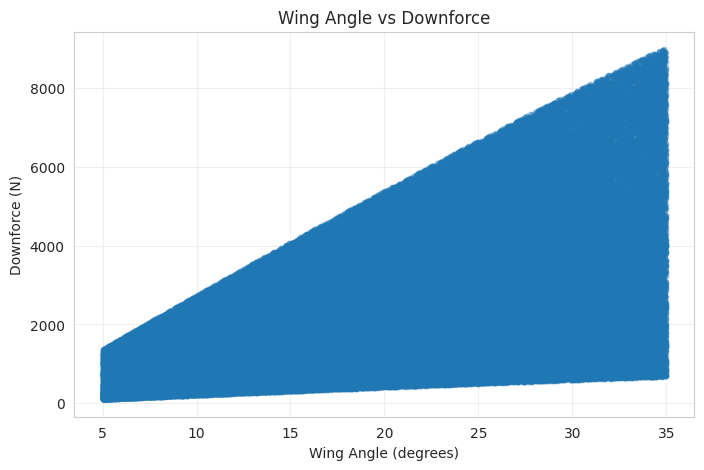

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["wing_angle_deg"],
    df["downforce_n"],
    alpha=0.3,
    s=10
)

plt.title("Wing Angle vs Downforce")
plt.xlabel("Wing Angle (degrees)")
plt.ylabel("Downforce (N)")
plt.grid(alpha=0.3)
plt.show()

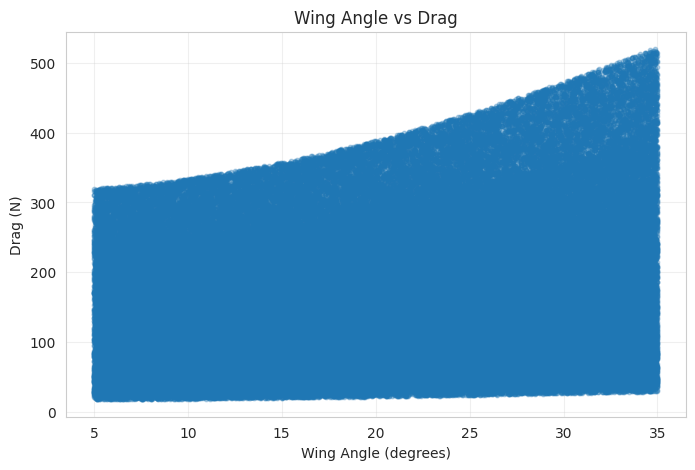

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["wing_angle_deg"],
    df["drag_n"],
    alpha=0.3,
    s=10
)

plt.title("Wing Angle vs Drag")
plt.xlabel("Wing Angle (degrees)")
plt.ylabel("Drag (N)")
plt.grid(alpha=0.3)
plt.show()

In [16]:
df.dtypes

,0
speed_kmh,float64
wing_angle_deg,float64
drs_active,int64
downforce_n,float64
drag_n,float64
stability_index,float64


In [23]:
encoded_df = pd.get_dummies(
    df,
    columns=["drs_active"],
    prefix="drs"
)

encoded_df.head()

,speed_kmh,wing_angle_deg,downforce_n,drag_n,stability_index,drs_0,drs_1
0,199.25,7.08,577.87,96.66,100.00,True,False
1,351.94,22.57,5617.09,378.93,44.15,True,False
2,293.98,28.97,4945.14,300.02,77.74,True,False
3,258.64,27.93,3702.69,227.46,100.00,True,False
4,141.34,30.12,1184.59,53.24,100.00,False,True


In [25]:
X = encoded_df.drop(['drs_0', 'drs_1'], axis=1)
y = encoded_df['drs_1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (119999, 5)  Test: (30000, 5)


In [26]:
print(X.columns.tolist())

['speed_kmh', 'wing_angle_deg', 'downforce_n', 'drag_n', 'stability_index']


In [27]:
# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.9853
Logistic Regression F1-Score: 0.9749


In [28]:
# Feature Importance for Logistic Regression

feature_importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Sort by absolute importance
feature_importance_log['Absolute_Coefficient'] = abs(
    feature_importance_log['Coefficient']
)

feature_importance_log = feature_importance_log.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance_log

,Feature,Coefficient,Absolute_Coefficient
3,drag_n,-0.879173,0.879173
0,speed_kmh,0.676309,0.676309
4,stability_index,-0.623946,0.623946
1,wing_angle_deg,0.322222,0.322222
2,downforce_n,0.011286,0.011286


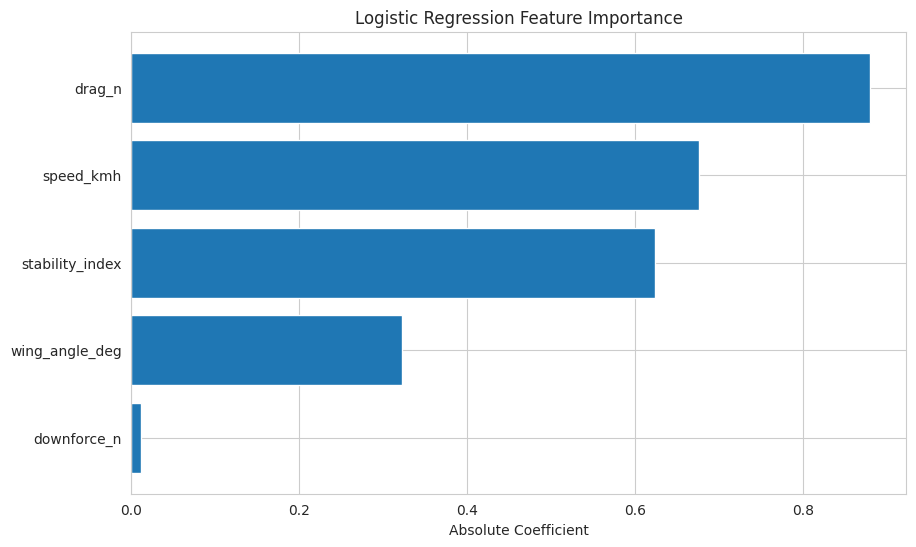

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_log['Feature'],
    feature_importance_log['Absolute_Coefficient']
)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.show()

In [31]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

Random Forest Accuracy: 0.8502
Random Forest F1-Score: 0.6658


In [33]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf

,Feature,Importance
3,drag_n,0.494501
0,speed_kmh,0.226478
2,downforce_n,0.172987
4,stability_index,0.074271
1,wing_angle_deg,0.031762


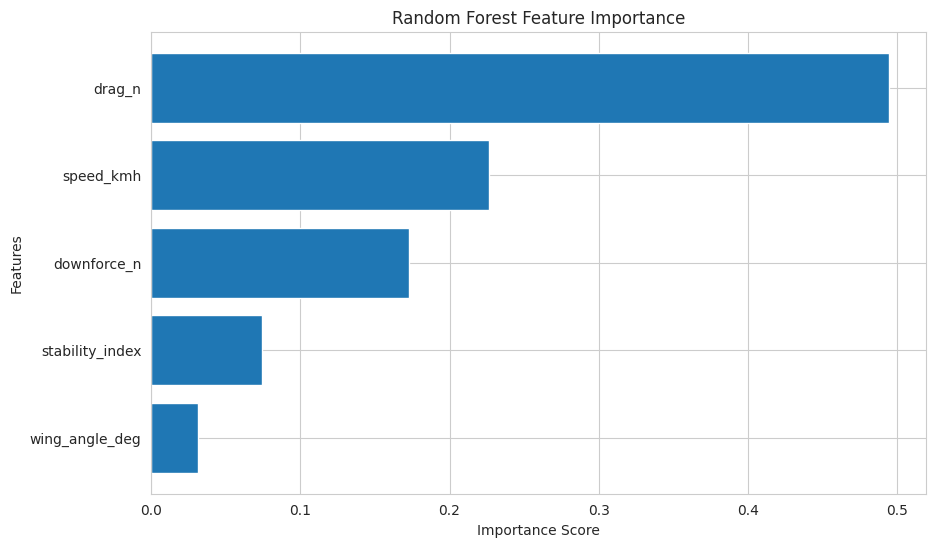

In [34]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf['Feature'],
    feature_importance_rf['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

In [36]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

XGBoost Accuracy: 1.0000
XGBoost F1-Score: 1.0000


In [37]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_xgb

,Feature,Importance
4,stability_index,0.334469
3,drag_n,0.251443
2,downforce_n,0.200286
0,speed_kmh,0.194314
1,wing_angle_deg,0.019487


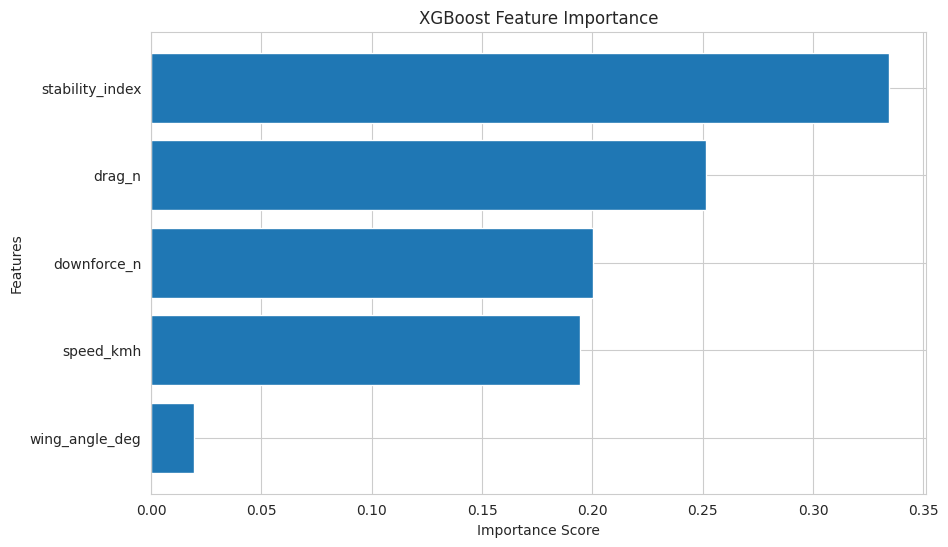

In [38]:
# XGBoost Feature Importance

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb['Feature'],
    feature_importance_xgb['Importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

In [39]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
    ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
    ]
})

comparison.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score
2,XGBoost,1.000000,1.000000
0,Logistic Regression,0.985333,0.974854
1,Random Forest,0.850233,0.665824


In [40]:
app_py_content = """
import streamlit as st
import joblib
import pandas as pd

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS

st.markdown('''

''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
        "https://cdn-icons-png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Models Used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

    ### Features

    - Real-time prediction
    - Risk probability
    - ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "💳 Loan Default Prediction System",
    unsafe_allow_html=True
)

st.markdown(
    "Machine Learning Powered Credit Risk Assessment Dashboard",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000
    )

    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000
    )

with col2:

    CreditScore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650
    )

    InterestRate = st.number_input(
        "Interest Rate (%)",
        min_value=1.0,
        max_value=40.0,
        value=10.0
    )

    LoanTerm = st.number_input(
        "Loan Term (Months)",
        min_value=6,
        max_value=360,
        value=36
    )

with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24
    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5
    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30
    )

# PREDICTION

if st.button("🔍 Predict Loan Risk"):

    # Create a dictionary for the input features
    input_dict = {
        'Age': [Age],
        'Income': [Income],
        'LoanAmount': [LoanAmount],
        'CreditScore': [CreditScore],
        'MonthsEmployed': [MonthsEmployed],
        'NumCreditLines': [NumCreditLines],
        'InterestRate': [InterestRate],
        'LoanTerm': [LoanTerm],
        'DTIRatio': [DTIRatio]
    }

    # Create a DataFrame from the input dictionary
    input_data_df = pd.DataFrame(input_dict)

    # Get the column names from the training data X
    # This list is obtained from the kernel state's 'X' variable.
    expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed',
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with all expected columns
    final_input_df = pd.DataFrame(columns=expected_columns)

    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0

    # Ensure the order of columns matches the training data 'X'
    final_input_df = final_input_df[expected_columns]

    prediction = model.predict(final_input_df)[0]

    probability = model.predict_proba(
        final_input_df
    )[0][1]

    st.divider()

    st.subheader("Prediction Result")

    colA, colB = st.columns(2)

    with colA:

        if prediction == 1:

            st.error(
                f'''
                ⚠️ HIGH DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
            )

        else:

            st.success(
                f'''
                ✅ LOW DEFAULT RISK

                Confidence:
                {(1-probability):.2%}
                '''
            )

    with colB:

        st.metric(
            "Default Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))
    st.metric(
        "Risk Level",
        "High Risk" if prediction == 1 else "Low Risk"
    )

# FOOTER

st.divider()

st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!
